In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance


In [2]:
from config import PITCHER_NAME, SEASONS
from data_pull import resolve_pitcher_id
from features import build_features

pitcher_id = resolve_pitcher_id(PITCHER_NAME)
df = build_features(pitcher_id, SEASONS)
print(df.shape)
print(df.columns.tolist())

Gathering player lookup table. This may take a moment.
Dropped 537 pitches with unclassified pitch_type
Dropping rare pitch types (< 2.0% usage):{'FC': np.float64(0.0067)}
(19370, 41)
['game_pk', 'pitch_type', 'release_speed', 'release_spin_rate', 'balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'game_date', 'at_bat_number', 'pitch_number', 'batter', 'pitcher', 'inning', 'inning_topbot', 'home_score', 'away_score', 'description', 'events', 'season', 'prev_pitch_type', 'prev_pitch_speed', 'prev_pitch_type_2', 'is_first_pitch_of_atbat', 'game_share_seen_CH', 'game_share_seen_CU', 'game_share_seen_FC', 'game_share_seen_FF', 'game_share_seen_SI', 'game_share_seen_SL', 'count_state', 'runner_on_1b', 'runner_on_2b', 'runner_on_3b', 'runners_on_base', 'platoon_matchup', 'score_diff']


In [3]:
df[(df["game_pk"] == 744912) & (df["at_bat_number"] == 9)]

,game_pk,pitch_type,release_speed,release_spin_rate,balls,strikes,outs_when_up,on_1b,on_2b,on_3b,...,game_share_seen_FF,game_share_seen_SI,game_share_seen_SL,count_state,runner_on_1b,runner_on_2b,runner_on_3b,runners_on_base,platoon_matchup,score_diff
11659,744912,SI,92.6,2122.0,1,0,0,NaN,NaN,NaN,...,0,0,0,1-0,False,False,False,0,opposite,3
11660,744912,SI,91.0,2145.0,2,0,0,NaN,NaN,NaN,...,0.0,1.0,0.0,2-0,False,False,False,0,opposite,3
11661,744912,SI,92.4,2030.0,2,1,0,NaN,NaN,NaN,...,0.0,1.0,0.0,2-1,False,False,False,0,opposite,3


In [4]:
from config import TRAIN_SEASONS, VAL_SEASON

print("Train seasons:", TRAIN_SEASONS)
print("Validation season:", VAL_SEASON)

train_df = df[df["season"].isin(TRAIN_SEASONS)].copy()
val_df = df[df["season"] == VAL_SEASON].copy()

print(f"Train rows: {len(train_df)} | Val rows: {len(val_df)}")

Train seasons: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
Validation season: 2026
Train rows: 17439 | Val rows: 1931


In [5]:
from sklearn.preprocessing import StandardScaler

target_col = "pitch_type"

categorical_features = [
    "count_state", "platoon_matchup", "prev_pitch_type", "prev_pitch_type_2",
    "stand", "p_throws", "inning_topbot",
]

numeric_features = [
    "balls", "strikes", "outs_when_up", "inning",
    "runners_on_base", "score_diff", "prev_pitch_speed",
    "is_first_pitch_of_atbat",
] + [c for c in df.columns if c.startswith("game_share_")]

feature_cols = categorical_features + numeric_features

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
    ]
)

print(f"{len(feature_cols)} features: {len(categorical_features)} categorical, "
      f"{len(numeric_features)} numeric")

21 features: 7 categorical, 14 numeric


In [6]:
def evaluate(model, X_val, y_val, label):
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)
    acc = accuracy_score(y_val, preds)
    macro_f1 = f1_score(y_val, preds, average="macro")
    ll = log_loss(y_val, probs, labels=model.classes_)
    print(f"{label:25s}  acc={acc:.3f}  macro_f1={macro_f1:.3f}  log_loss={ll:.3f}")
    return {"model": label, "accuracy": acc, "macro_f1": macro_f1, "log_loss": ll}

results = []

baseline = Pipeline([
    ("prep", preprocessor),
    ("clf", DummyClassifier(strategy="prior")),
])

baseline.fit(X_train, y_train)
results.append(evaluate(baseline, X_val, y_val, "Baseline (majority class)"))

Baseline (majority class)  acc=0.459  macro_f1=0.126  log_loss=1.268


In [7]:
logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)
results.append(evaluate(logreg, X_val, y_val, "Logistic Regression"))

Logistic Regression        acc=0.503  macro_f1=0.289  log_loss=1.145


In [8]:
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    )),
])
rf.fit(X_train, y_train)
results.append(evaluate(rf, X_val, y_val, "Random Forest"))

Random Forest              acc=0.505  macro_f1=0.253  log_loss=1.135


In [9]:
hgb = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6, random_state=42
    )),
])
hgb.fit(X_train, y_train)
results.append(evaluate(hgb, X_val, y_val, "HistGradientBoosting"))

HistGradientBoosting       acc=0.500  macro_f1=0.275  log_loss=1.149


In [10]:
for name, model in [("Logistic Regression", logreg), ("Random Forest", rf), ("HistGradientBoosting", hgb)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"{name:25s}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  gap={train_acc - val_acc:.3f}")

Logistic Regression        train_acc=0.563  val_acc=0.503  gap=0.060
Random Forest              train_acc=0.581  val_acc=0.505  gap=0.076
HistGradientBoosting       train_acc=0.643  val_acc=0.500  gap=0.143


In [11]:
hgb_small = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        max_iter=100, learning_rate=0.05, max_depth=3, random_state=42
    )),
])
hgb_small.fit(X_train, y_train)
results.append(evaluate(hgb_small, X_val, y_val, "HistGradientBoosting (shallow)"))

train_acc = accuracy_score(y_train, hgb_small.predict(X_train))
val_acc = accuracy_score(y_val, hgb_small.predict(X_val))
print(f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  gap={train_acc - val_acc:.3f}")

HistGradientBoosting (shallow)  acc=0.500  macro_f1=0.278  log_loss=1.133
train_acc=0.583  val_acc=0.500  gap=0.083


In [12]:
hgb_mid = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        max_iter=150, learning_rate=0.05, max_depth=4, random_state=42
    )),
])
hgb_mid.fit(X_train, y_train)
results.append(evaluate(hgb_mid, X_val, y_val, "HistGradientBoosting (mid)"))

train_acc = accuracy_score(y_train, hgb_mid.predict(X_train))
val_acc = accuracy_score(y_val, hgb_mid.predict(X_val))
print(f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  gap={train_acc - val_acc:.3f}")

HistGradientBoosting (mid)  acc=0.501  macro_f1=0.277  log_loss=1.138
train_acc=0.608  val_acc=0.501  gap=0.107


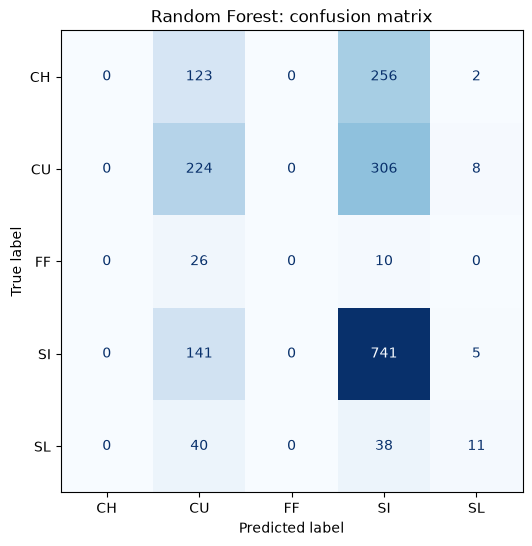

In [14]:
preds = rf.predict(X_val)
cm = confusion_matrix(y_val, preds, labels=rf.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest: confusion matrix")
plt.show()

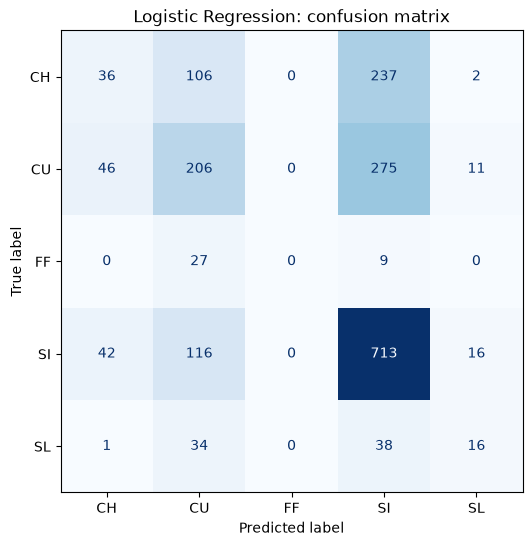

In [16]:
preds = logreg.predict(X_val)
cm = confusion_matrix(y_val, preds, labels=logreg.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression: confusion matrix")
plt.show()

In [17]:
logreg_balanced = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
logreg_balanced.fit(X_train, y_train)
results.append(evaluate(logreg_balanced, X_val, y_val, "Logistic Regression (balanced)"))

Logistic Regression (balanced)  acc=0.340  macro_f1=0.276  log_loss=1.407


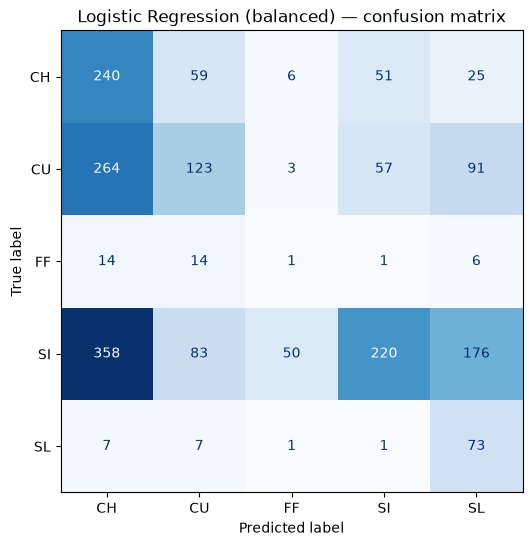

In [18]:
preds = logreg_balanced.predict(X_val)
cm = confusion_matrix(y_val, preds, labels=logreg_balanced.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_balanced.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression (balanced) — confusion matrix")
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

logreg_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000)),
])

search = GridSearchCV(
    logreg_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="accuracy", 
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best cross-validated accuracy:", search.best_score_)

Best params: {'clf__C': 0.1, 'clf__class_weight': None}
Best cross-validated accuracy: 0.5499655884377151


In [21]:
best_logreg = search.best_estimator_
results.append(evaluate(best_logreg, X_val, y_val, "Logistic Regression (tuned)"))

Logistic Regression (tuned)  acc=0.506  macro_f1=0.288  log_loss=1.144
